In [293]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

appl_data = pd.read_csv("C:/Users/Logesh Raja Mu/Downloads/application_data.csv")
prev_appl = pd.read_csv("C:/Users/Logesh Raja Mu/Downloads/previous_application.csv")

#Data Understanding
# Display the first 5 rows of the dataframes.head()
appl_data.head()


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [73]:
#Seeing the shape of the dataframe
appl_data.shape

(307511, 122)

In [75]:
#Seeing the info of the dataframe
appl_data.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [89]:
#Seeing the datatypes of each field in dataframe
appl_data.dtypes

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

In [105]:
#Data Cleaning
#Finding the percentage of missing values in each column
appl_data.isnull().sum()/len(appl_data)*100

SK_ID_CURR                     0.000000
TARGET                         0.000000
NAME_CONTRACT_TYPE             0.000000
CODE_GENDER                    0.000000
FLAG_OWN_CAR                   0.000000
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
Length: 122, dtype: float64

In [107]:
#Finding out coloums having greater than 50% null value

emptycolumn=appl_data.isnull().sum()/len(appl_data)*100
emptycolumn=emptycolumn[emptycolumn.values>50.0]
print(emptycolumn)
len(emptycolumn)

OWN_CAR_AGE                 65.990810
EXT_SOURCE_1                56.381073
APARTMENTS_AVG              50.749729
BASEMENTAREA_AVG            58.515956
YEARS_BUILD_AVG             66.497784
COMMONAREA_AVG              69.872297
ELEVATORS_AVG               53.295980
ENTRANCES_AVG               50.348768
FLOORSMIN_AVG               67.848630
LANDAREA_AVG                59.376738
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAREA_AVG              50.193326
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAREA_AVG           55.179164
APARTMENTS_MODE             50.749729
BASEMENTAREA_MODE           58.515956
YEARS_BUILD_MODE            66.497784
COMMONAREA_MODE             69.872297
ELEVATORS_MODE              53.295980
ENTRANCES_MODE              50.348768
FLOORSMIN_MODE              67.848630
LANDAREA_MODE               59.376738
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAREA_MODE             50.193326
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAREA_MODE          55.179164
APARTMENTS_M

41

In [109]:
#Deleting all columns having more than 50% null values
emptycolumn = list(emptycolumn[emptycolumn.values>=50.0].index)
appl_data.drop(labels=emptycolumn,axis=1,inplace=True)
print(len(emptycolumn))

41


In [111]:
#Seeing the shape of the dataframe after removing columns
appl_data.shape

(307511, 81)

In [117]:
#Seeing coloums having less than 19% null value
emptycolumn=appl_data.isnull().sum()/len(appl_data)*100
emptycolumn=emptycolumn[emptycolumn.values<19.0]
print(emptycolumn)
len(emptycolumn)

SK_ID_CURR                     0.000000
TARGET                         0.000000
NAME_CONTRACT_TYPE             0.000000
CODE_GENDER                    0.000000
FLAG_OWN_CAR                   0.000000
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
Length: 71, dtype: float64


71

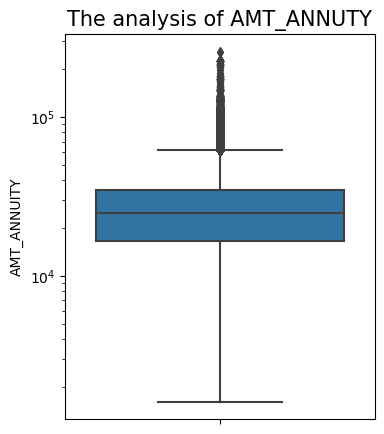

In [161]:
#AMT_ANNUITY column plotting using box plot to detect outliers
plt.figure(figsize=(4,5))
sns.boxplot(y=appl_data['AMT_ANNUITY'])
plt.yscale('log') #to print matplotlib.pyplot with a logarithmic y-axis scale.
plt.title("The analysis of AMT_ANNUTY",fontsize=15)
plt.show()

In [139]:
#Finding out the information of the column AMT_ANNUITY
print(appl_data['AMT_ANNUITY'].mean())
print(appl_data['AMT_ANNUITY'].median())
print(appl_data['AMT_ANNUITY'].describe())

27108.573909183444
24903.0
count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64


In [143]:
# Inference:
#The Box Plot reveals the presence of several outliers, indicating a significant disparity between the maximum and minimum values.
#Therefore, we have decided to use the median value to replace the null values.

In [145]:
#Finding out the count of missing value for AMT_ANNUITY column
appl_data.AMT_ANNUITY.isnull().sum()

12

In [147]:
# Inserting the missing values in column AMT_ANNUITY with the median value
fillMissingValue=appl_data['AMT_ANNUITY'].median()
appl_data['AMT_ANNUITY'].fillna(value = fillMissingValue, inplace =True)

In [149]:
#Finding out the count of missing value for AMT_ANNUITY column
appl_data.AMT_ANNUITY.isnull().sum()

0

In [151]:
# Seeing the columns having less null percentage value
appl_data.isnull().sum()/len(appl_data)*100

SK_ID_CURR                     0.000000
TARGET                         0.000000
NAME_CONTRACT_TYPE             0.000000
CODE_GENDER                    0.000000
FLAG_OWN_CAR                   0.000000
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
Length: 81, dtype: float64

In [153]:
#Analysis of the CNT_FAM_MEMBERS
#Finding out the count of family members
appl_data['CNT_FAM_MEMBERS'].value_counts(dropna=False)

CNT_FAM_MEMBERS
2.0     158357
1.0      67847
3.0      52601
4.0      24697
5.0       3478
6.0        408
7.0         81
8.0         20
9.0          6
10.0         3
NaN          2
14.0         2
12.0         2
20.0         2
16.0         2
13.0         1
15.0         1
11.0         1
Name: count, dtype: int64

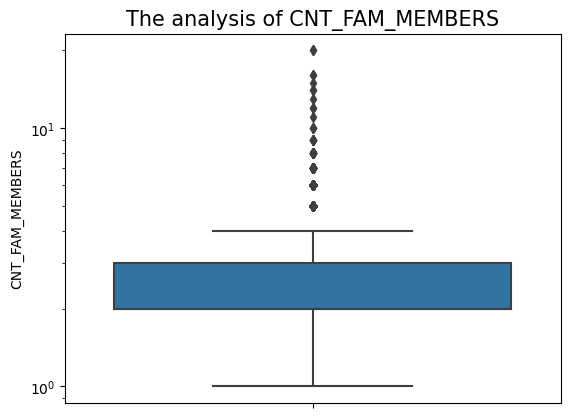

In [159]:
#CNT_FAM_MEMBERS column values plotting using box plot to detect the outliers
sns.boxplot(y=appl_data['CNT_FAM_MEMBERS'])
plt.yscale('log')
plt.title("The analysis of CNT_FAM_MEMBERS",fontsize=15)
plt.show()

In [163]:
#Seeing information of column CNT_FAM_MEMBERS
print(appl_data['CNT_FAM_MEMBERS'].mean())
print(appl_data['CNT_FAM_MEMBERS'].median())
print(appl_data['CNT_FAM_MEMBERS'].describe())

2.152665450442101
2.0
count    307509.000000
mean          2.152665
std           0.910682
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64


In [167]:
# Inserting the missing values with median
fillMissingVal=appl_data['CNT_FAM_MEMBERS'].median()
appl_data['CNT_FAM_MEMBERS'].fillna(value = fillMissingVal, inplace =True)

In [169]:
#Finding out the count of missing value in the CNT_FAM_MEMBERS column
appl_data.CNT_FAM_MEMBERS.isnull().sum()

0

In [171]:
# Checking the columns having less null percentage
appl_data.isnull().sum()/len(appl_data)*100

SK_ID_CURR                     0.000000
TARGET                         0.000000
NAME_CONTRACT_TYPE             0.000000
CODE_GENDER                    0.000000
FLAG_OWN_CAR                   0.000000
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
Length: 81, dtype: float64

In [173]:
#Inference:
#The BoxPlot indicates the presence of significant outliers and a notable difference between the 75th percentile and the maximum value.
#Consequently, we will use the median value to replace the null values.

In [175]:
#Analysis of the code : gender
#Finding out the count of each gender M and F
appl_data['CODE_GENDER'].value_counts(dropna=False)

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

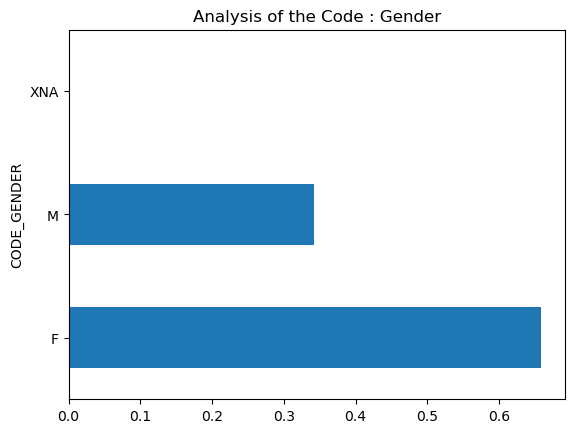

In [177]:
#plotting the bar graph of CODE_GENDER
appl_data['CODE_GENDER'].value_counts(normalize=True).plot.barh(title='Analysis of the Code : Gender')
plt.show()

In [179]:
#The analysis of ORGANIZATION_TYPE
#Finding out the count of each type of organization where the client works
appl_data['ORGANIZATION_TYPE'].value_counts(dropna=False)

ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7      

In [181]:
#printing the info of the column : ORGANIZATION_TYPE
print(appl_data['ORGANIZATION_TYPE'].mode())
print(appl_data['ORGANIZATION_TYPE'].describe())

0    Business Entity Type 3
Name: ORGANIZATION_TYPE, dtype: object
count                     307511
unique                        58
top       Business Entity Type 3
freq                       67992
Name: ORGANIZATION_TYPE, dtype: object


In [183]:
#Inference:
#There are 55,374 rows with XNA values, which constitute 18% of the total dataset. 
#Therefore, we can choose to discard these rows.

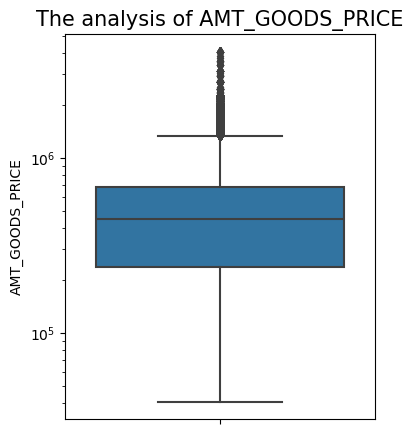

In [185]:
# The analysis of AMT_GOODS_PRICE
#box-plotting the values of AMT_GOODS_PRICE
plt.figure(figsize=(4,5))
sns.boxplot(y=appl_data['AMT_GOODS_PRICE'])
plt.yscale('log') #to display matplotlib.pyplot with a logarithmic y-axis scale.
plt.title("The analysis of AMT_GOODS_PRICE",fontsize=15)
plt.show()

In [187]:
#printing the info of the column AMT_GOODS_PRICE
print(appl_data['AMT_GOODS_PRICE'].describe())
print(appl_data['AMT_GOODS_PRICE'].median())
print(appl_data['AMT_GOODS_PRICE'].mean())
print(appl_data['AMT_GOODS_PRICE'].max())
print(appl_data['AMT_GOODS_PRICE'].min())

count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64
450000.0
538396.2074288895
4050000.0
40500.0


In [189]:
#Inference:
#Since the data does not provide a clear understanding, we will retain the null values.

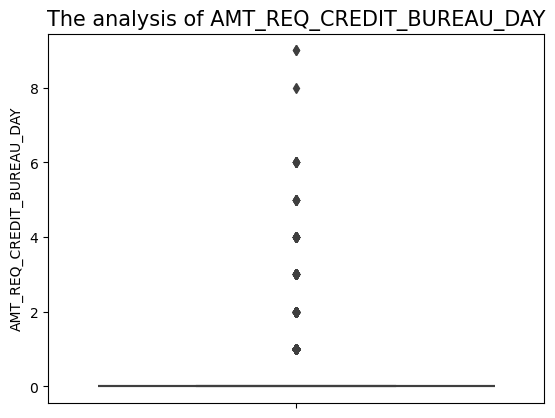

In [191]:
#The analysis of AMT_REQ_CREDIT_BUREAU_DAY
#box plotting the values of AMT_REQ_CREDIT_BUREAU_DAY
sns.boxplot(y=appl_data['AMT_REQ_CREDIT_BUREAU_DAY'])
plt.title("The analysis of AMT_REQ_CREDIT_BUREAU_DAY",fontsize=15)
plt.show()

In [525]:
#Printing the info of column AMT_REQ_CREDIT_BUREAU_DAY
print(appl_data['AMT_REQ_CREDIT_BUREAU_DAY'].describe())

count    265992.000000
mean          0.007000
std           0.110757
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           9.000000
Name: AMT_REQ_CREDIT_BUREAU_DAY, dtype: float64


In [195]:
#Inference:
#The numerical column AMT_REQ_CREDIT_BUREAU_DAY contains outliers that should either be removed or capped.
#Additionally, for handling missing values, we should use the median.

In [221]:
# Deleting the outliers for the column AMT_REQ_CREDIT_BUREAU_DAY
col_of_outliers = ['AMT_REQ_CREDIT_BUREAU_DAY']
for col in col_of_outliers:
    # Calculate percentiles
    percentiles = appl_data[col].quantile([0.01, 0.99]).values
    # Cap outliers using .loc to avoid SettingWithCopyWarning
    appl_data.loc[appl_data[col] <= percentiles[0], col] = percentiles[0]
    appl_data.loc[appl_data[col] >= percentiles[1], col] = percentiles[1]

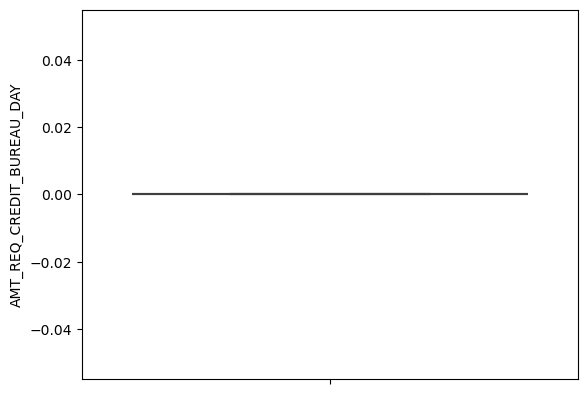

In [225]:
# Box-plotting the values of AMT_REQ_CREDIT_BUREAU_DAY
sns.boxplot(y=appl_data['AMT_REQ_CREDIT_BUREAU_DAY'])
plt.show()

In [227]:
#Altering the datatype for required columns
appl_data.dtypes

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 81, dtype: object

In [231]:
# Casting all the variables into numeric in dataset
numeric_columns=['TARGET','CNT_CHILDREN','AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','REGION_POPULATION_RELATIVE','DAYS_BIRTH',
                'DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH','HOUR_APPR_PROCESS_START','LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY']

appl_data[numeric_columns]=appl_data[numeric_columns].apply(pd.to_numeric)
appl_data.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [409]:
# Doing the binning process
# Creating bins for the income amount
bins_income = [0,25000,50000,75000,100000,125000,150000,175000,200000,225000,250000,275000,300000,325000,350000,375000,400000,425000,450000,475000,500000,10000000000]
slot_income = ['0-25000', '25000-50000','50000-75000','75000,100000','100000-125000', '125000-150000', '150000-175000','175000-200000','200000-225000',
               '225000-250000','250000-275000','275000-300000','300000-325000','325000-350000','350000-375000','375000-400000','400000-425000',
               '425000-450000','450000-475000','475000-500000','500000 and above']

appl_data['AMT_INCOME_RANGE']=pd.cut(appl_data['AMT_INCOME_TOTAL'],bins_income,labels=slot_income)

In [411]:
# Creating bins for the Credit amount

bins_credit = [0,150000,200000,250000,300000,350000,400000,450000,500000,550000,600000,650000,700000,750000,800000,850000,900000,1000000000]
slot_credit = ['0-150000', '150000-200000','200000-250000', '250000-300000', '300000-350000', '350000-400000','400000-450000','450000-500000',
               '500000-550000','550000-600000','600000-650000','650000-700000','700000-750000','750000-800000','800000-850000','850000-900000',
               '900000 and above']

appl_data['AMT_CREDIT_RANGE']=pd.cut(appl_data['AMT_CREDIT'],bins_credit,labels=slot_credit)

In [237]:
# Splitting the dataset into two datasets of target=1 (client with payment difficulties) and target=0 (all others)
target_0 = appl_data.loc[appl_data["TARGET"]==0]
target_1 = appl_data.loc[appl_data["TARGET"]==1]

In [251]:
# Finding out the imbalance percentage
imbal=round(len(target_0)/len(target_1),2)
imbal

11.39

In [283]:
#Univariate analysis for categories
#creating a reusable plotting function

def plotfunction(df, column, title, hue=None):
    
    # Set the style and context for seaborn plots
    sns.set_style('darkgrid')
    sns.set_context('poster')
    
    # Configure font sizes and padding for the plot
    plt.rcParams["axes.labelsize"] = 16
    plt.rcParams['axes.titlesize'] = 20
    plt.rcParams['axes.titlepad'] = 32
    
    # Create a new figure and axis for the plot
    fig, ax = plt.subplots()
    
    # Adjust the figure size based on the number of unique values in the column and hue
    width = len(df[column].unique()) + 7 + 4 * len(pd.Series(data=hue).unique())
    fig.set_size_inches(width, 10)
    
    # Set the y-axis to a logarithmic scale
    plt.yscale('log')
    
    # Set the plot title with a specific font size
    plt.title(title, fontsize=16)
    
    # Create a count plot with the specified column and hue, using a bright color palette
    ax = sns.countplot(data=df, x=column, hue=hue, palette='bright', dodge=True) if hue else sns.countplot(data=df, x=column, palette='bright', dodge=True)
    
    # Rotate x-axis labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Display the plot
    plt.show()


D:\Anaconda\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
D:\Anaconda\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


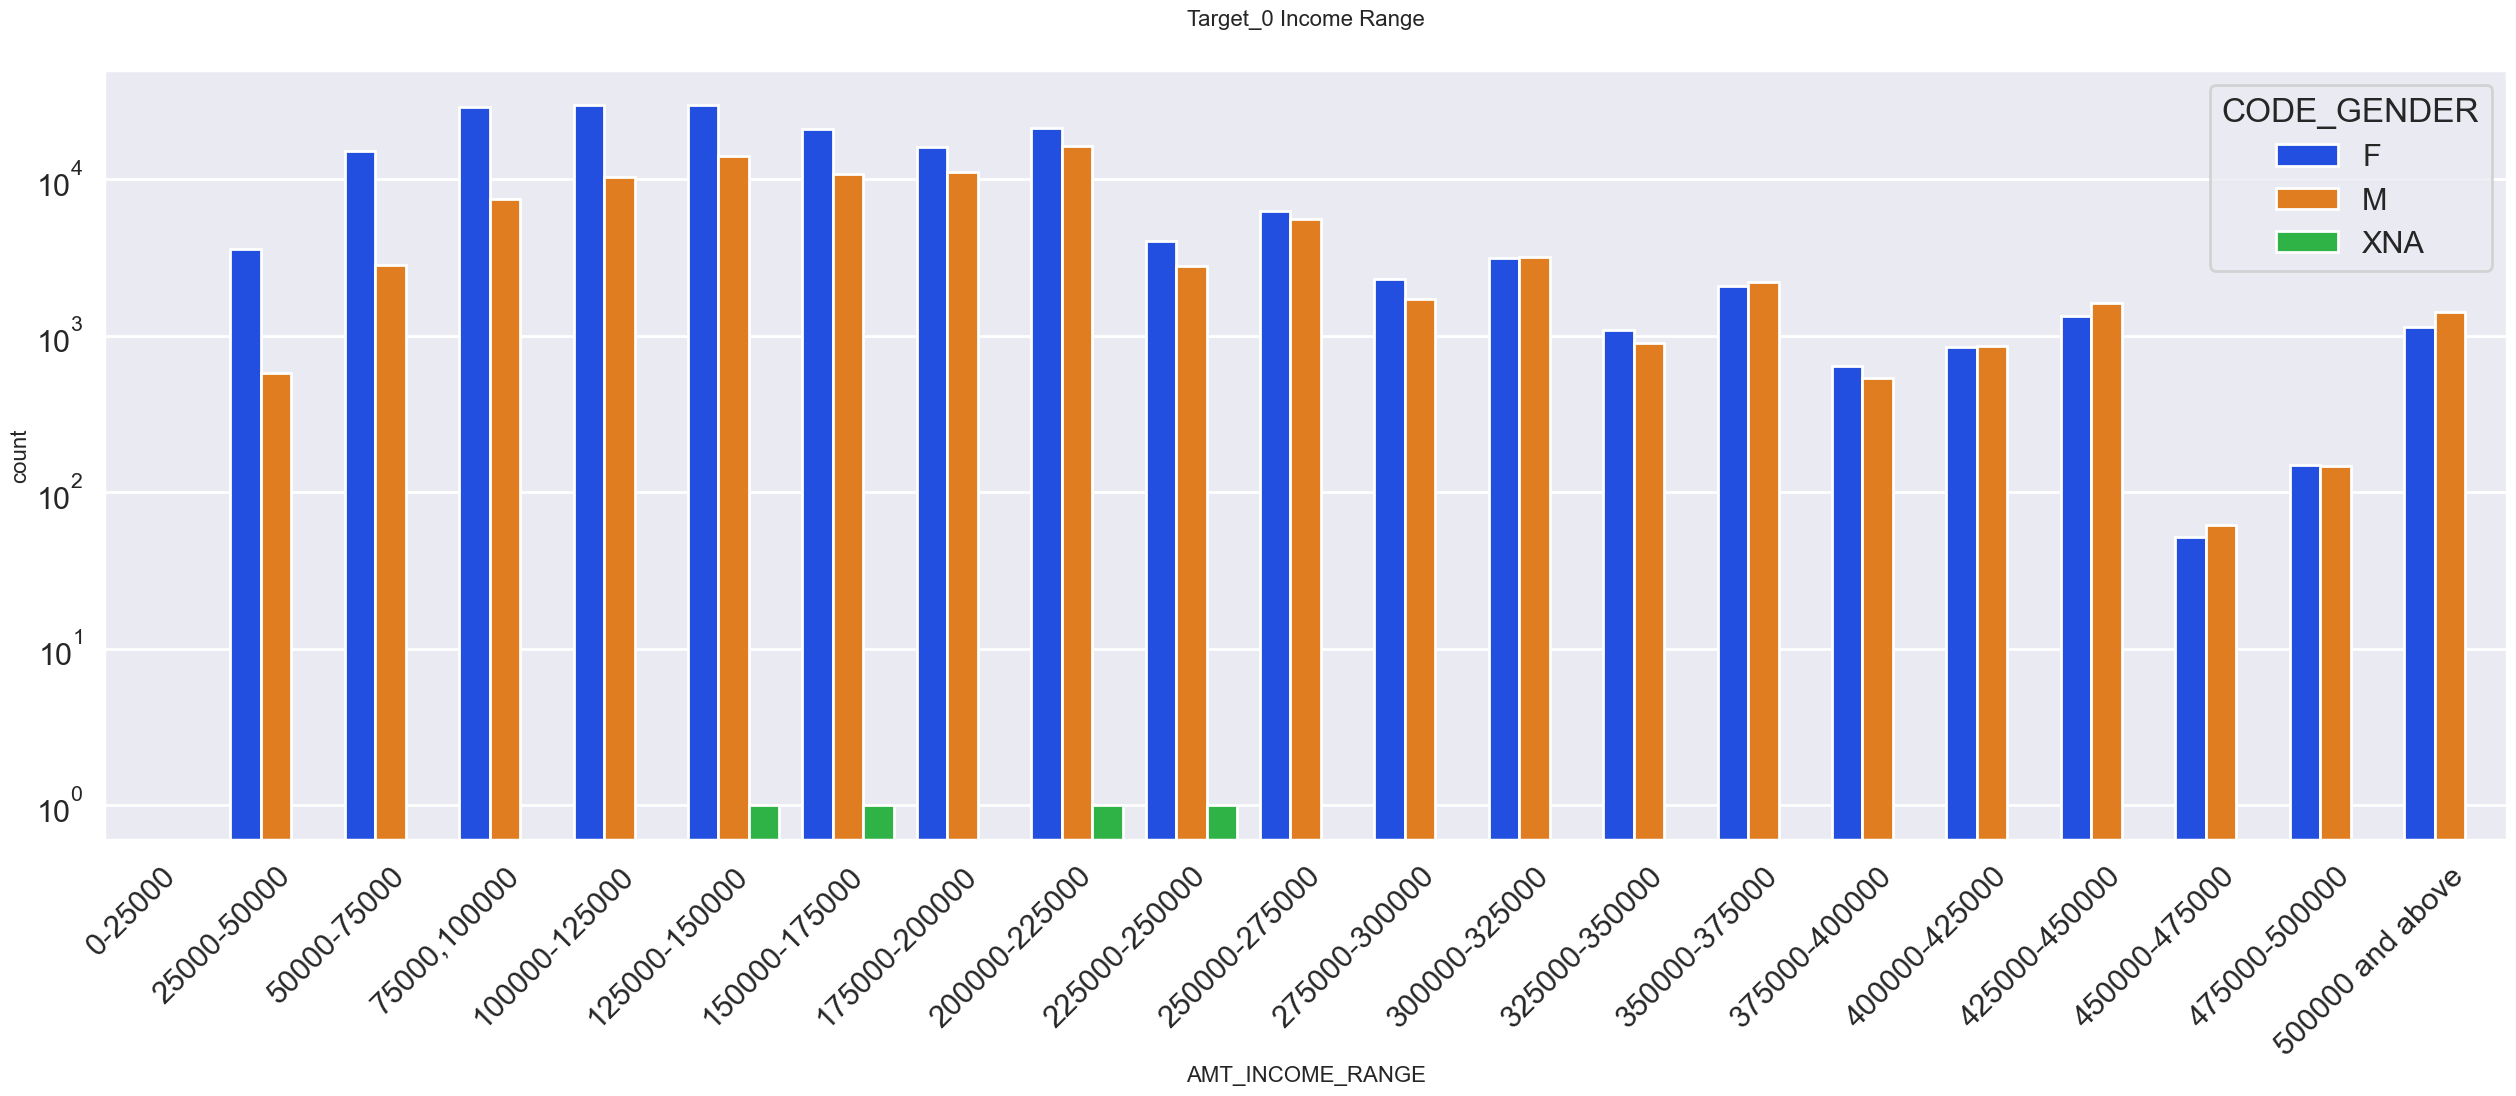

In [301]:
# Plotting for income range for target_0
plotfunction(target_0,column='AMT_INCOME_RANGE',title='Target_0 Income Range',hue='CODE_GENDER')

In [291]:
#Inference:
#Key takeaways from the graph for target=0 (Non-Defaulters) are:
#The number of females is greater than that of males.
#The data indicates that females have more credits in the specified range compared to males.

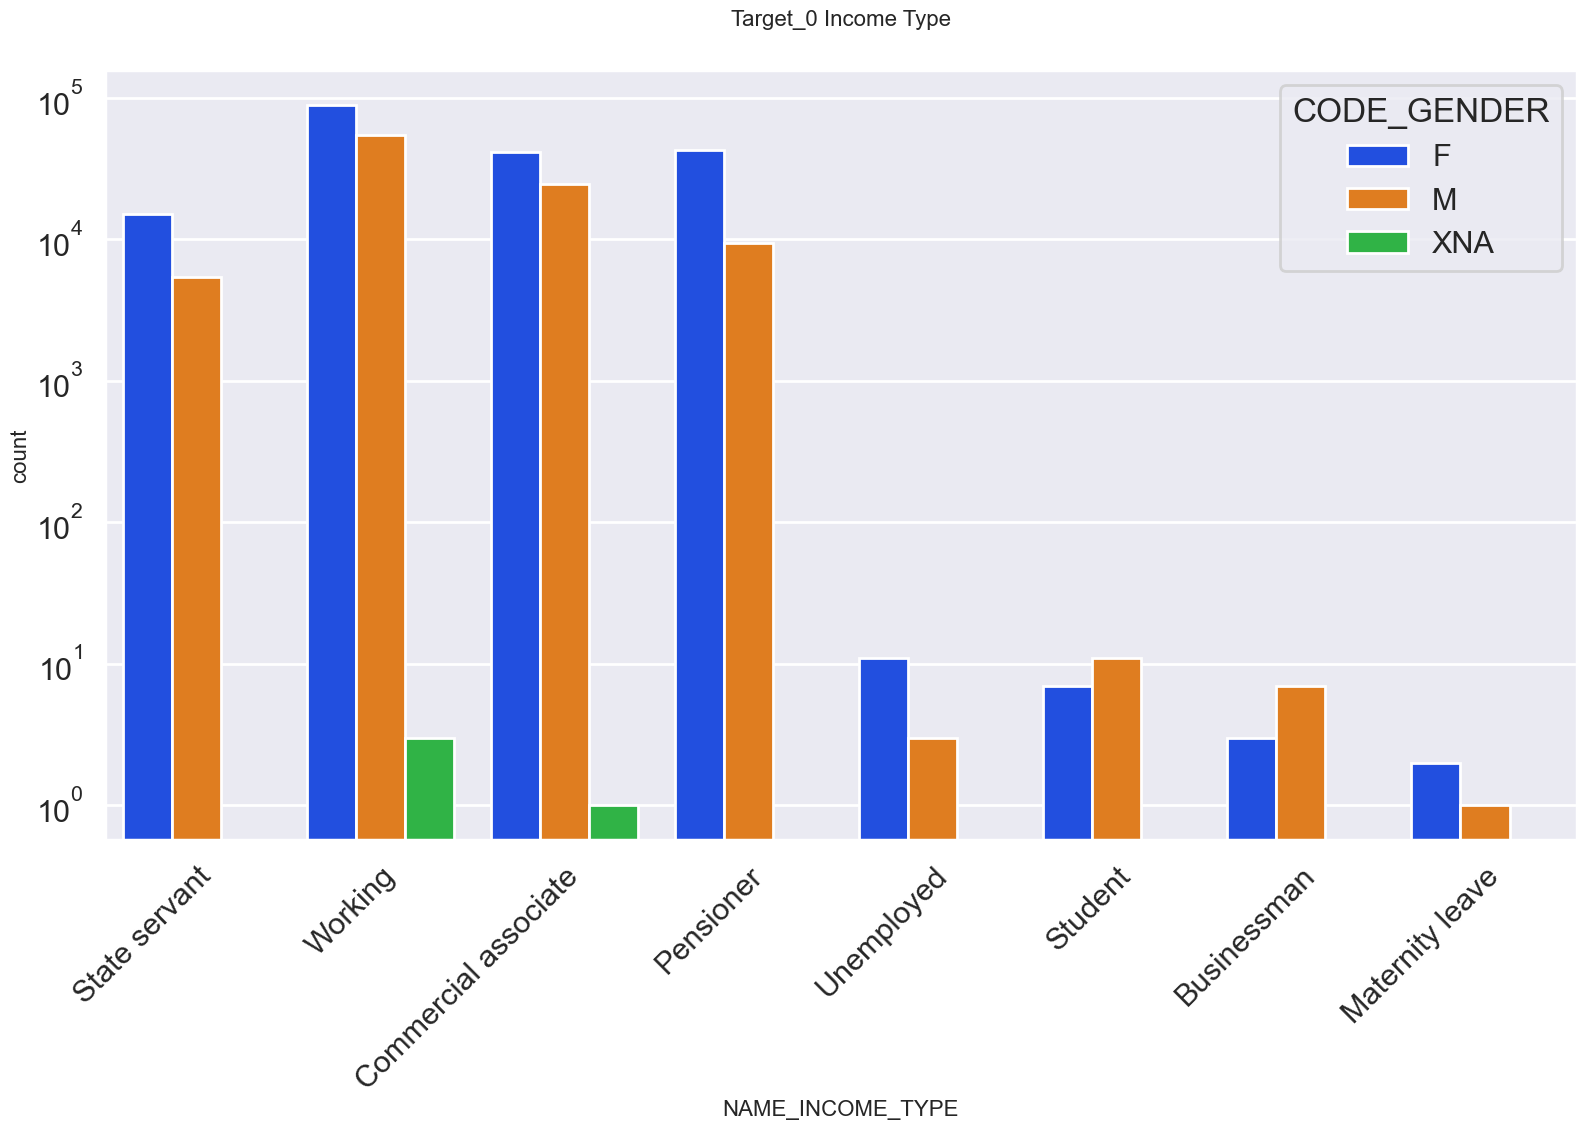

In [303]:
# Plotting for the Income type for the target 0
plotfunction(target_0,column='NAME_INCOME_TYPE',title='Target_0 Income Type',hue='CODE_GENDER')

In [305]:
#Inference:
#Key observations from the graph for Target_0 (Non-Defaulters) are:
#Females have higher credit counts compared to males.
#The highest credit counts are associated with income types such as working, commercial associate, pensioner, and state servant.
#The lowest credit counts are associated with income types such as student, unemployed, businessman, and maternity leave.

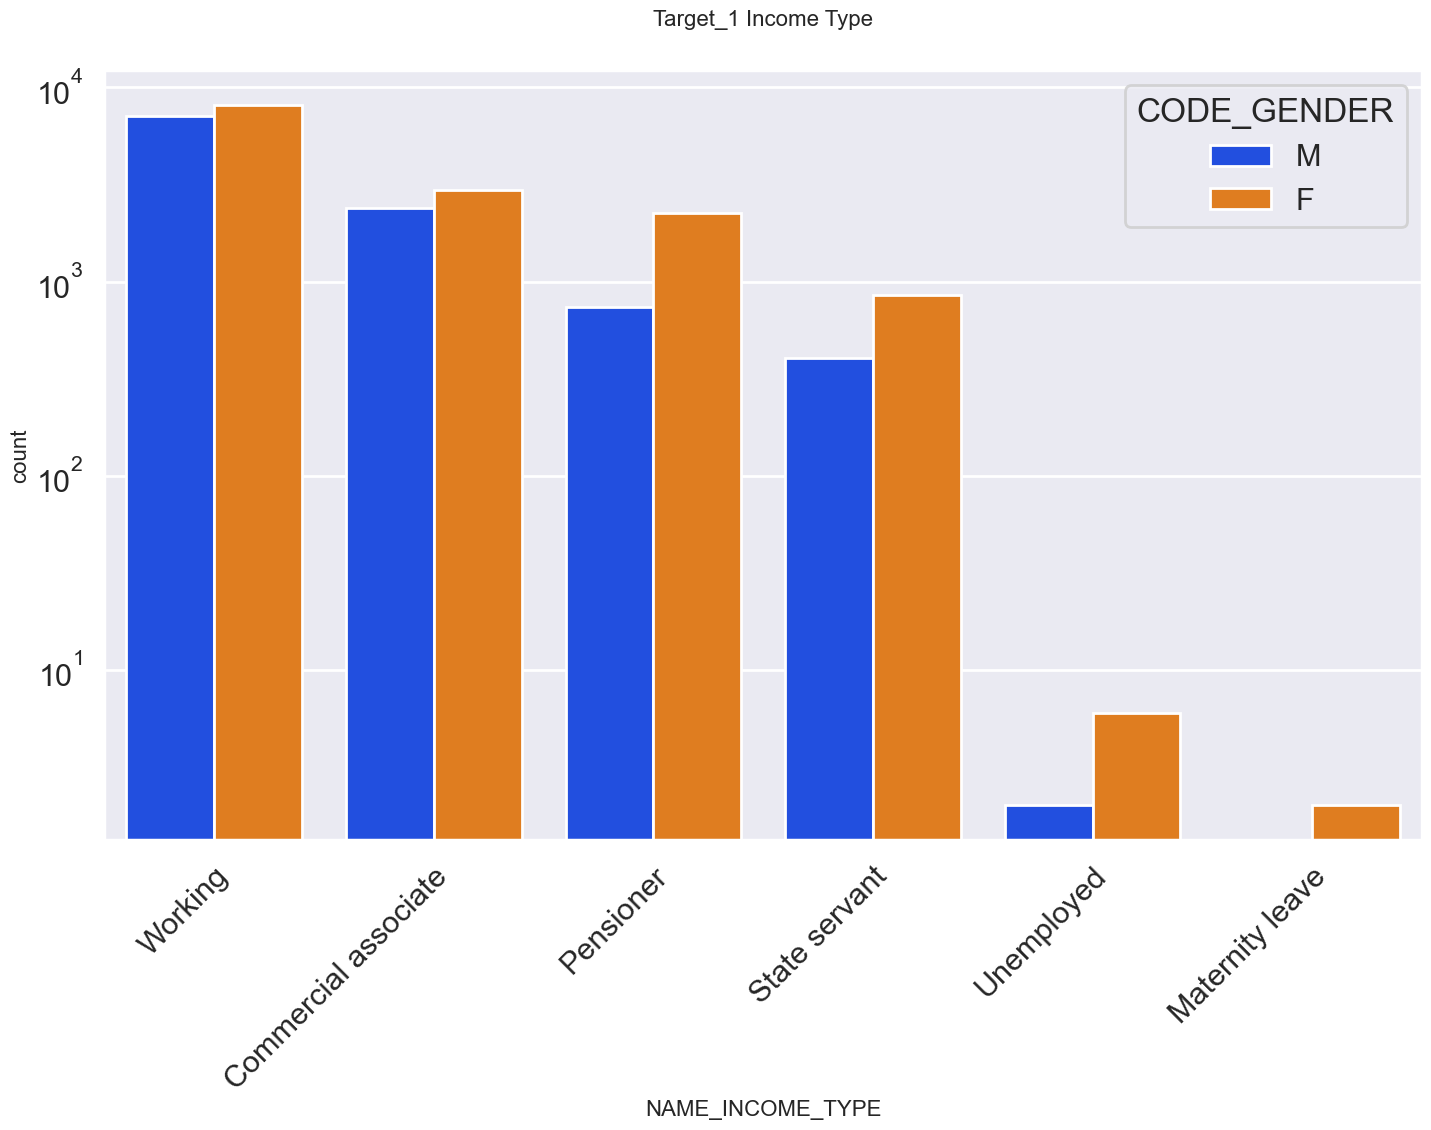

In [309]:
# Plotting for the income Type for target_1
plotfunction(target_1,column='NAME_INCOME_TYPE',title='Target_1 Income Type',hue='CODE_GENDER')

In [311]:
#Inference:
#Key observations from the graph for Target=1 (Defaulters) are:
#The highest credit counts are seen for income types such as working, commercial associate, pensioner, and state servant, similar to Target=0.
#The lowest credit counts are observed for income types such as unemployed and maternity leave.

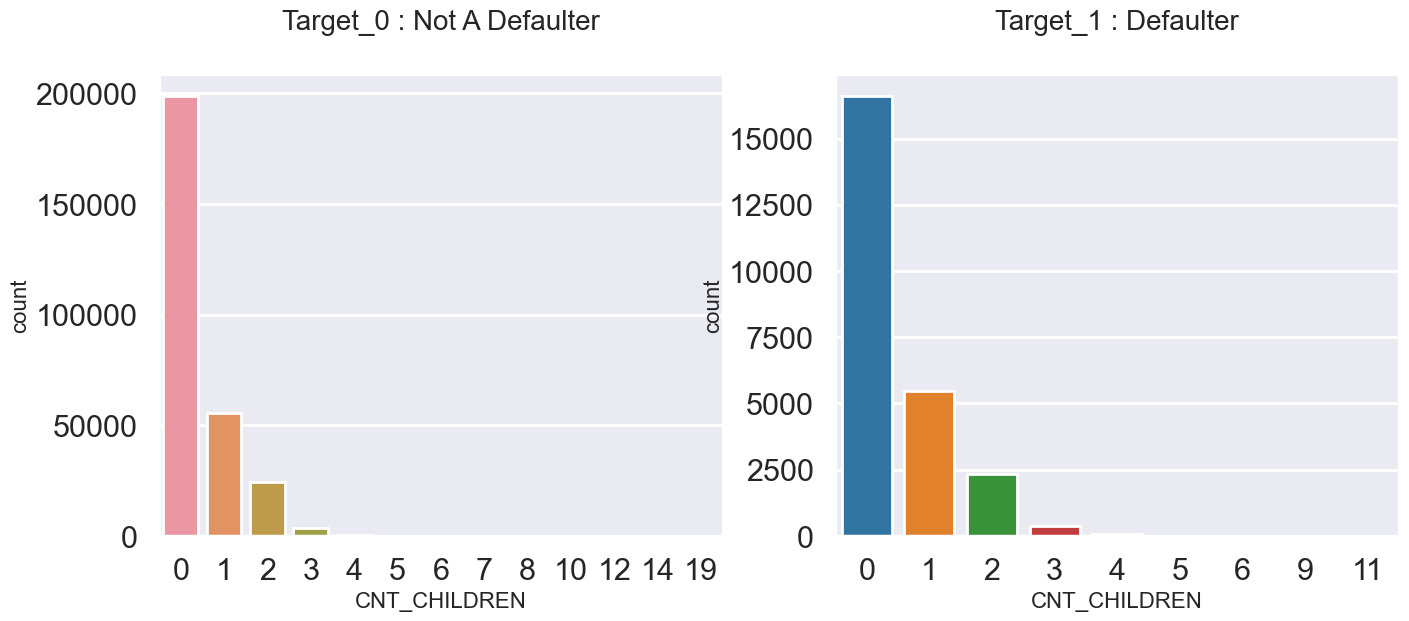

In [327]:
# Plotting for CNT_CHILDREN for target_0 & target_1
fig, ax = plt.subplots(1,2,figsize=(16,6))
sns.countplot(x=target_0['CNT_CHILDREN'], ax=ax[0]).set_title('Target_0 : Not A Defaulter')
sns.countplot(x=target_1['CNT_CHILDREN'], ax=ax[1]).set_title('Target_1 : Defaulter')
plt.show()

In [329]:
#Inference:
#Key takeaways from the graph:
#A low number of children is associated with both higher chances of being a defaulter and non-defaulter. 
#Therefore, no specific conclusions can be drawn from this data exploration.

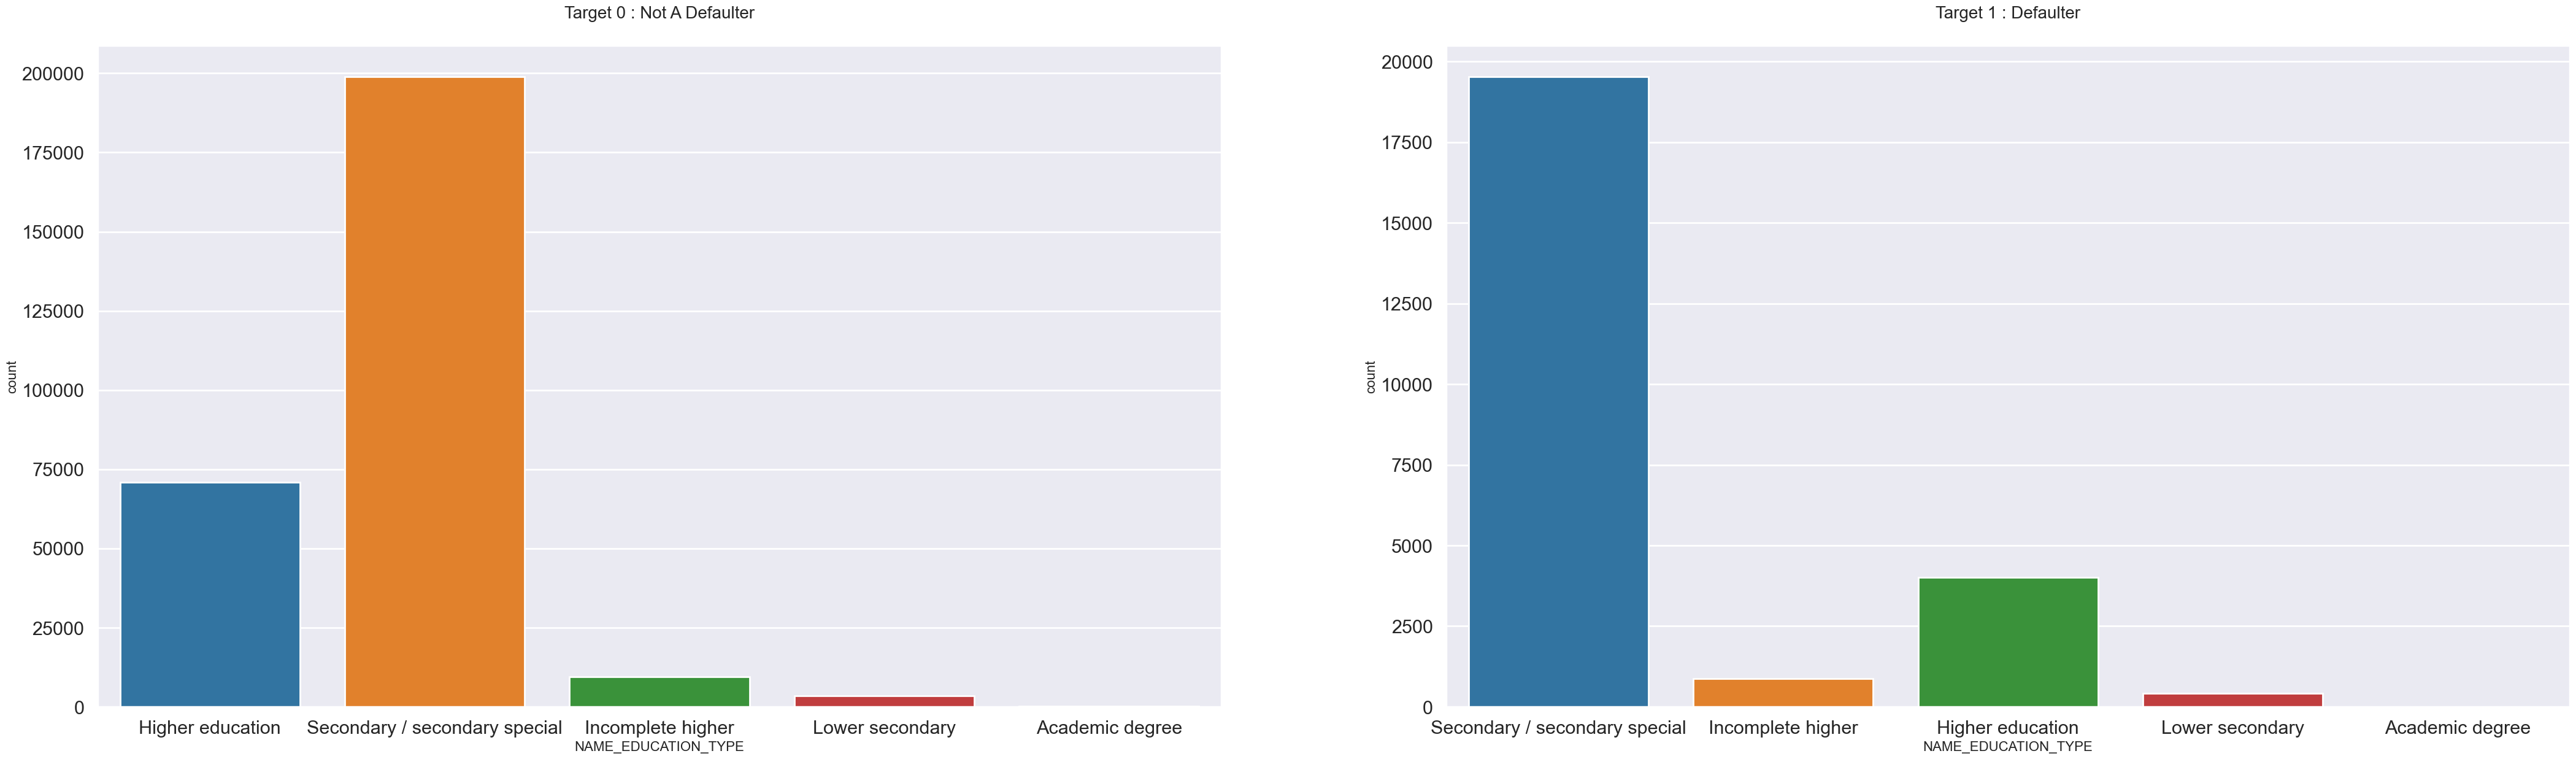

In [331]:
# Plotting for NAME_EDUCATION_TYPE for target_0 & target_1
fig, ax=plt.subplots(1,2,figsize=(52,14))
sns.countplot(x=target_0['NAME_EDUCATION_TYPE'], ax=ax[0]).set_title('Target 0 : Not A Defaulter')
sns.countplot(x=target_1['NAME_EDUCATION_TYPE'], ax=ax[1]).set_title('Target 1 : Defaulter')
plt.show()

In [333]:
#Inference:
#Key observations from the graph:
#The comparison reveals that individuals with secondary education have the highest rate of defaulting.

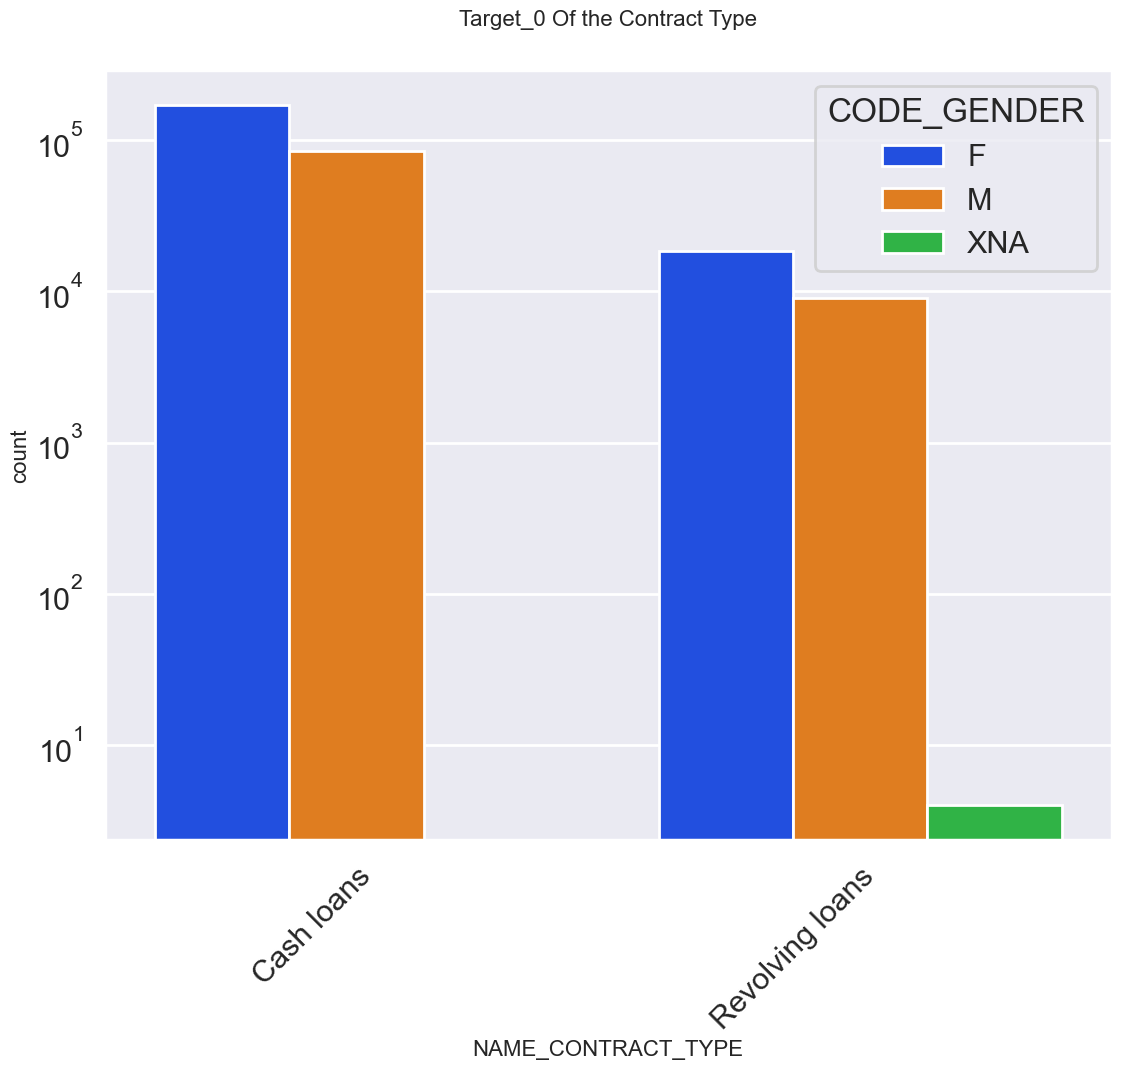

In [371]:
#Plotting for the NAME_CONTRACT_TYPE for target_0
plotfunction(target_0,column='NAME_CONTRACT_TYPE',title='Target_0 Of the Contract Type',hue='CODE_GENDER')

In [337]:
#Inference:
#Key takeaways from the graph for Target=0 (Non-Defaulters):
#Cash loan contracts have a higher number of credits compared to revolving loan contracts.
#The count of females is higher.

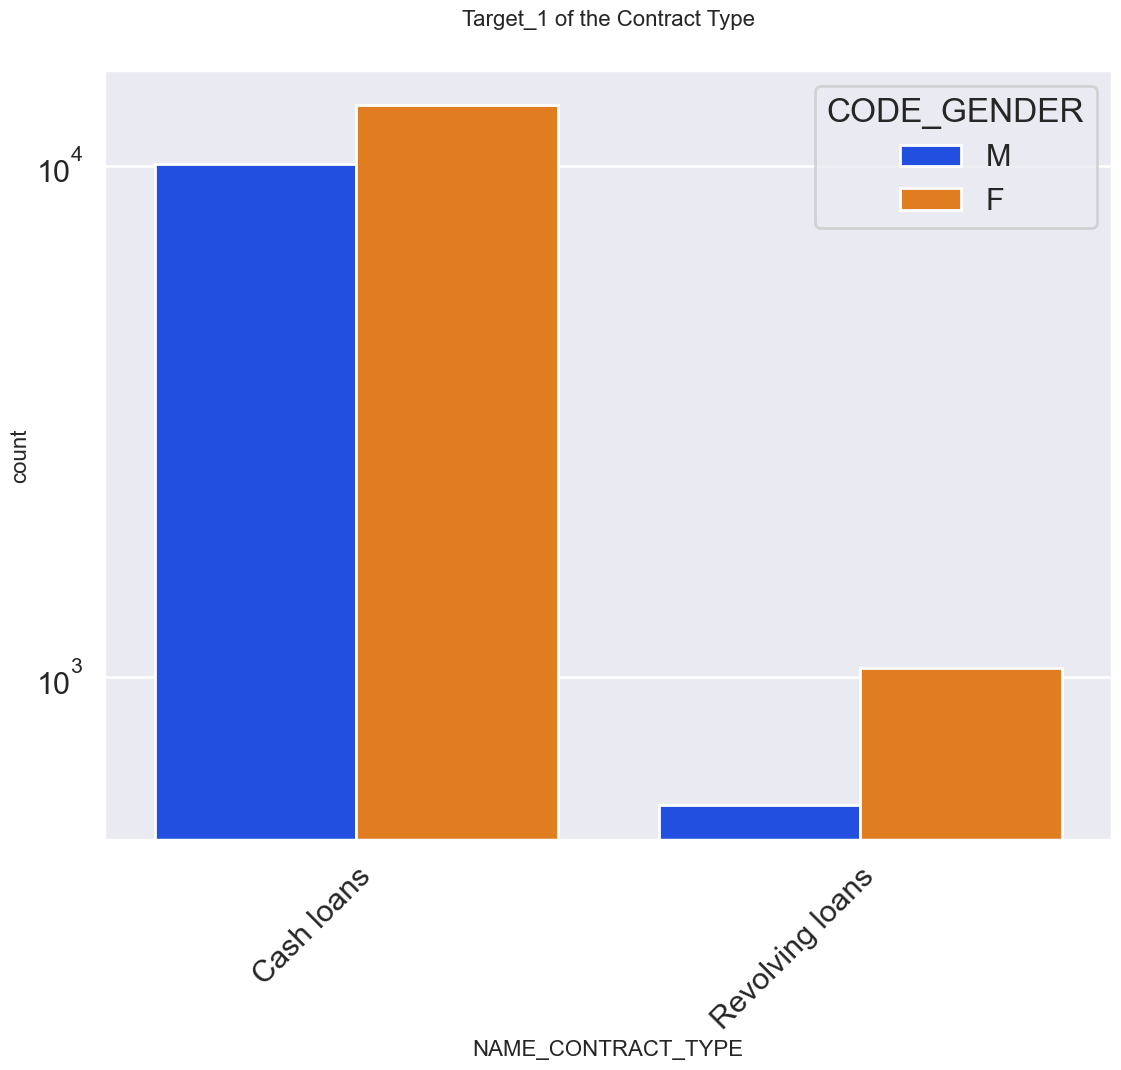

In [339]:
#Plotting for the NAME_CONTRACT_TYPE for target_1
plotfunction(target_1,column='NAME_CONTRACT_TYPE',title='Target_1 of the Contract Type',hue='CODE_GENDER')

In [341]:
#Inference:
#Key takeaways from the graph for Target = 1 (Defaulters):
#Cash loan contracts have a higher number of credits compared to revolving loan contracts.
#Revolving loans are exclusively held by females.

In [389]:
#Continuous Univariate Analysis
#Function for the box plot
def conBoxPlot(data,column,title):
    sns.set_style('darkgrid')
    sns.set_context('poster')
    plt.rcParams["axes.labelsize"] = 16
    plt.rcParams['axes.titlesize'] = 20
    plt.rcParams['axes.titlepad'] = 32
    
    plt.title(title)
    plt.yscale('log')
    sns.boxplot(data =data, y=column,color="red")
    plt.show()


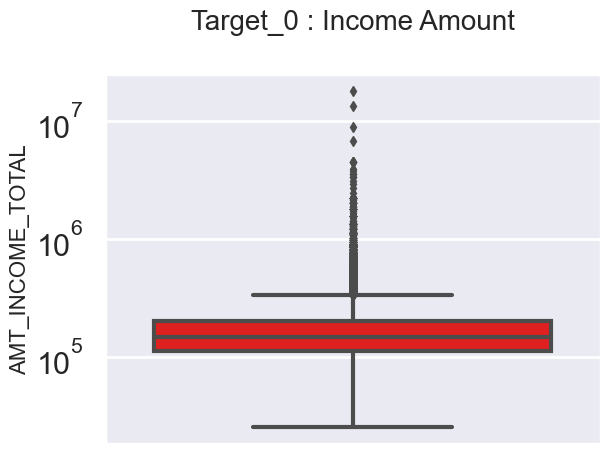

In [391]:
#Spread of income amount for Target_0
conBoxPlot(data=target_0,column='AMT_INCOME_TOTAL',title='Target_0 : Income Amount')

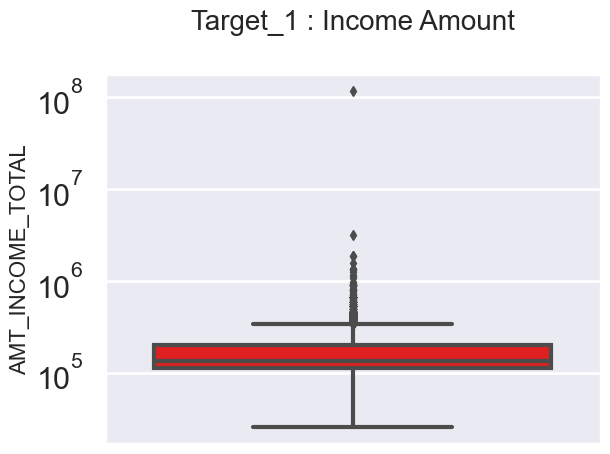

In [395]:
#Spread of income amount for Target_1
conBoxPlot(data=target_1,column='AMT_INCOME_TOTAL',title='Target_1 : Income Amount')

In [397]:
#Inference:
#Key observations from the two graphs:
#Outliers are present in both datasets.
#The third quartile is relatively narrow for both Target 1 and Target 0.
#The majority of clients have income levels in the first quartile.

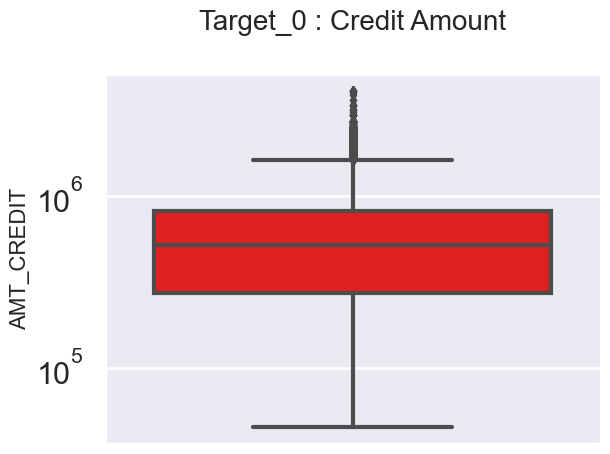

In [399]:
#Spread of credit amount for Target_0
conBoxPlot(data=target_0,column='AMT_CREDIT',title='Target_0 : Credit Amount')

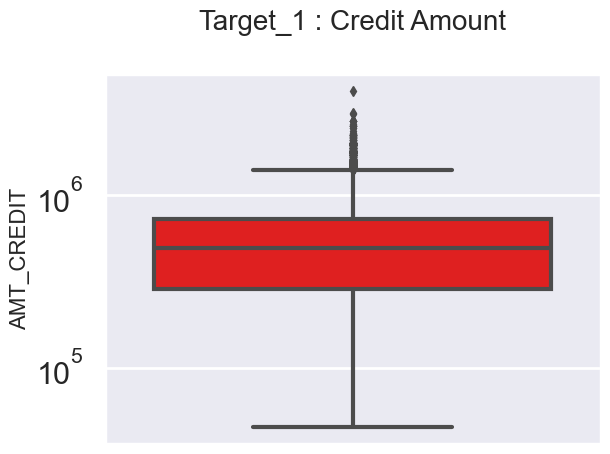

In [401]:
#Spread of credit amount for Target_1
conBoxPlot(data=target_1,column='AMT_CREDIT',title='Target_1 : Credit Amount')

In [403]:
#Inference:
#Key takeaways from the two graphs:
#Outliers are evident in both datasets.
#The third quartile is narrow for both Target 1 and Target 0.
#The majority of clients have credit amounts in the first quartile.

In [405]:
#Bivariate Analysis
#Examining the correlation for numerical columns for Target_0 & Target_1

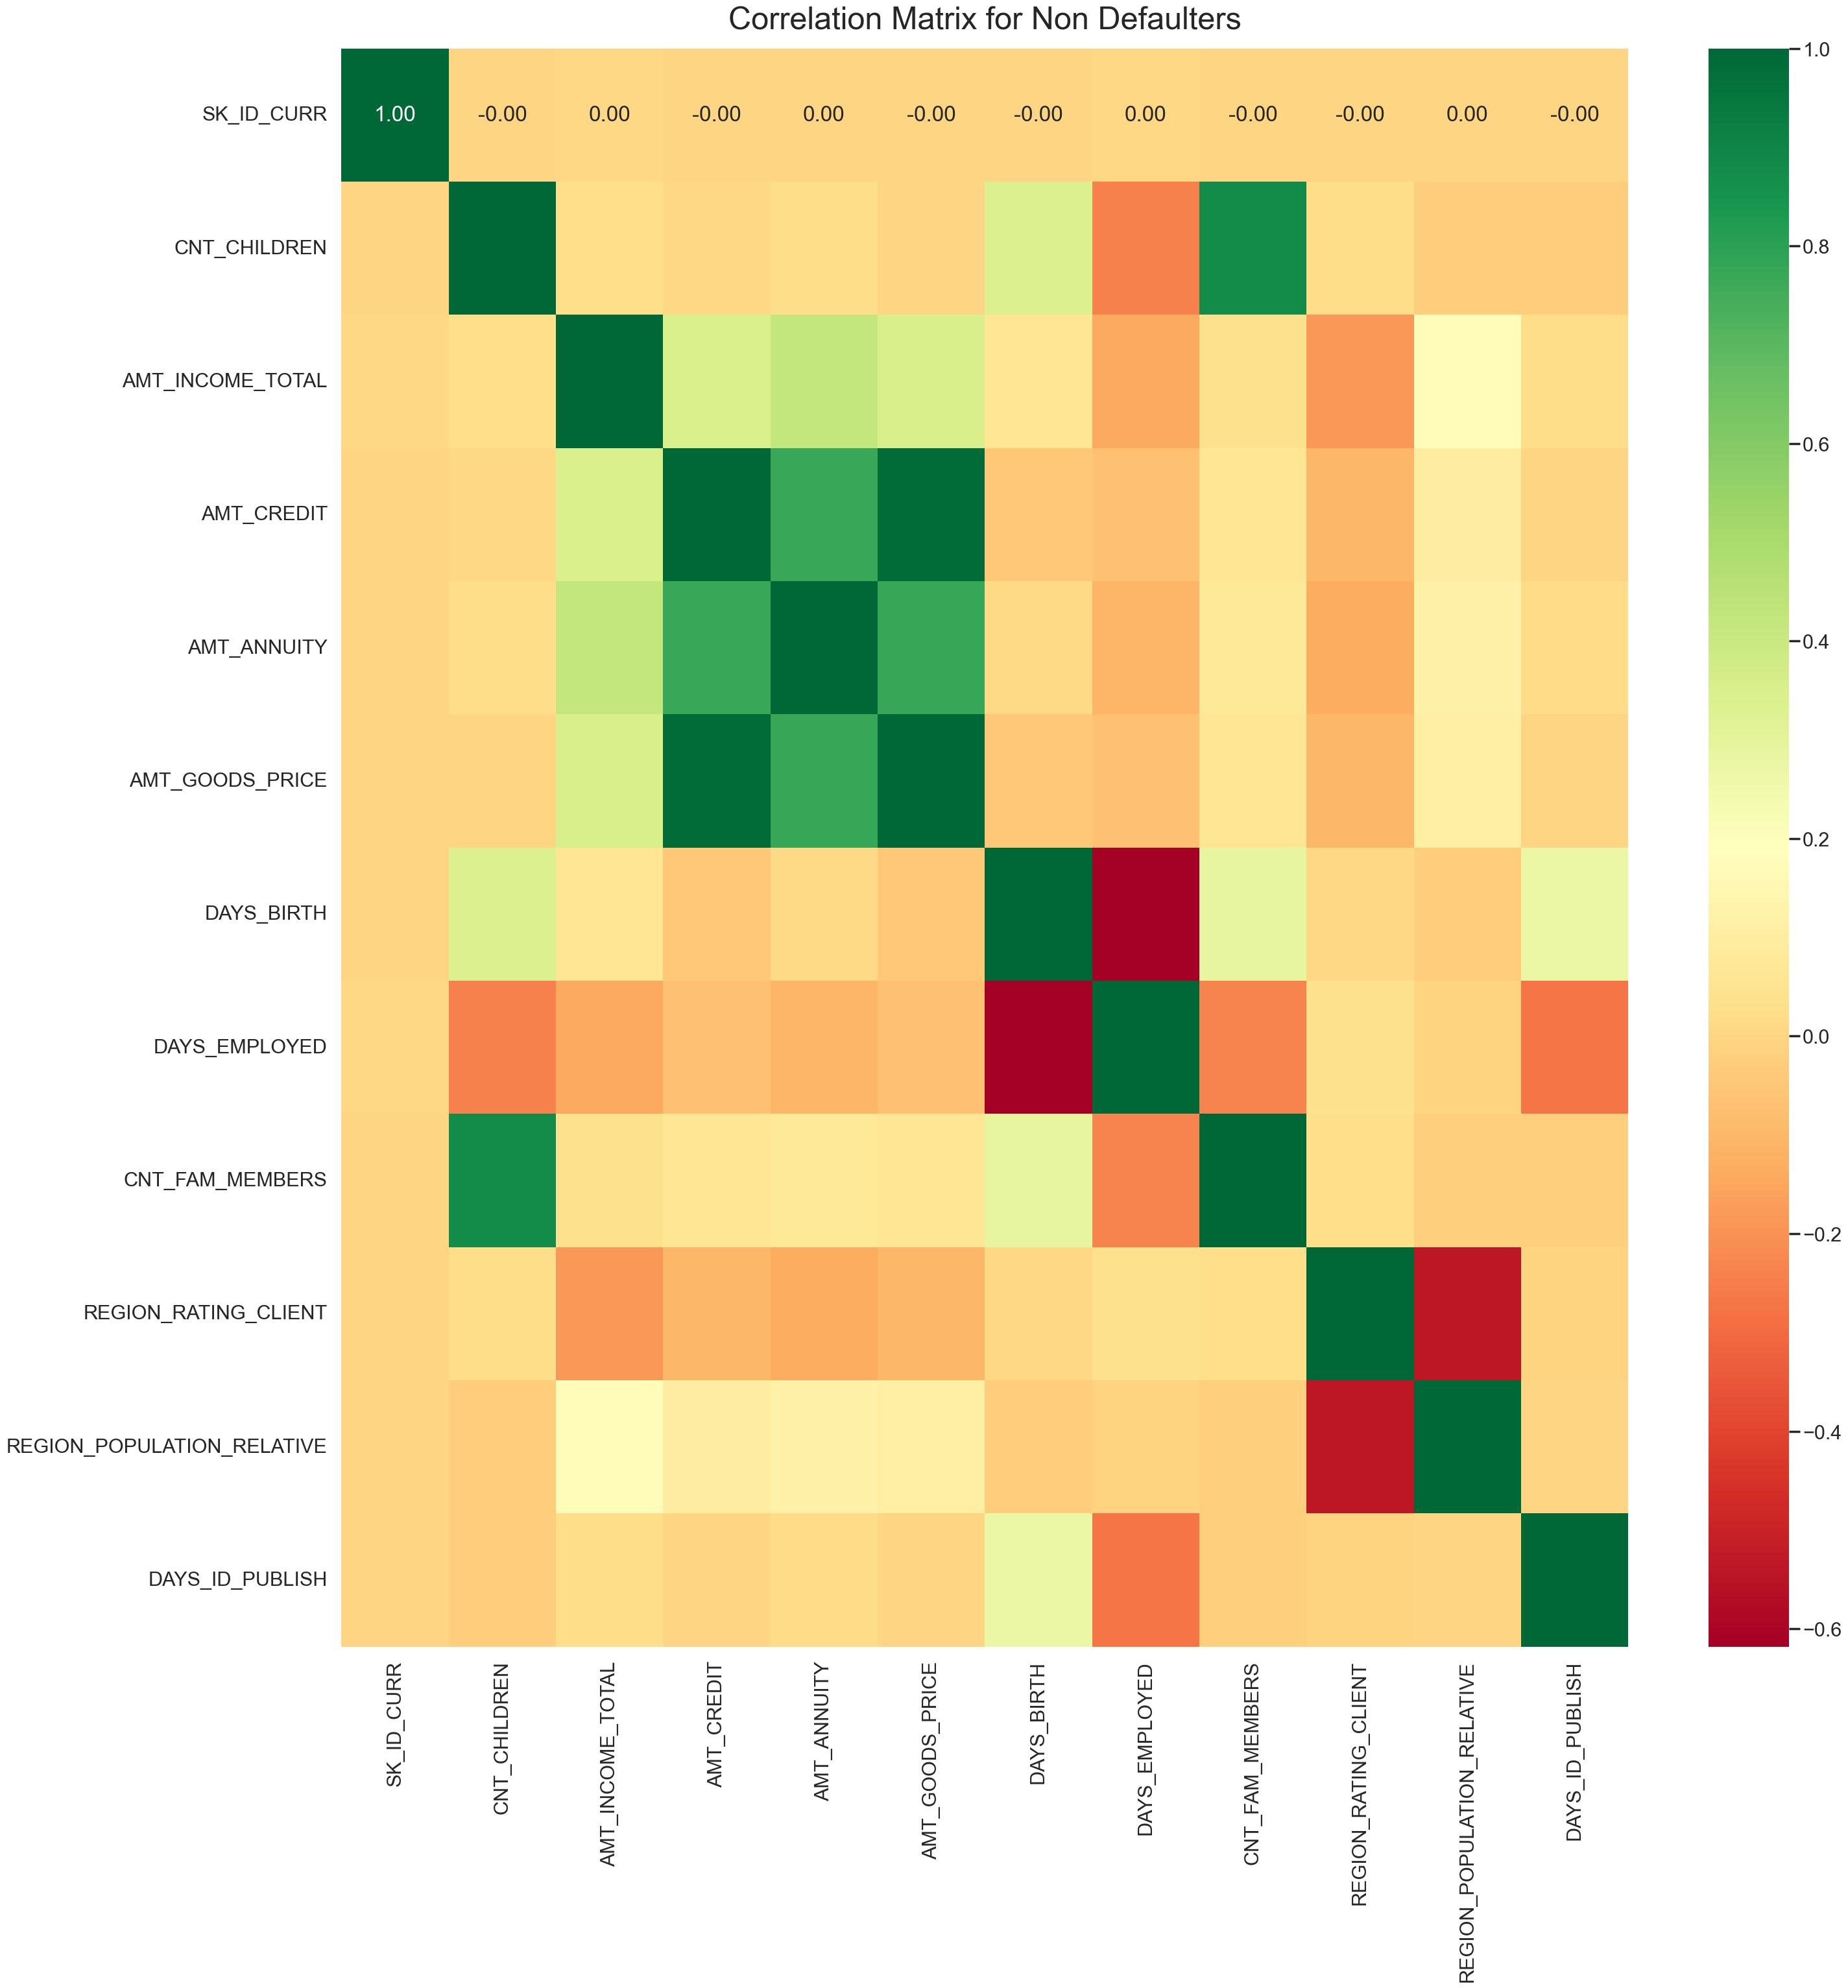

In [415]:
#Plotting the correlation matrix for Target_0 appl_data
m=target_0[['SK_ID_CURR','CNT_CHILDREN','AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE','DAYS_BIRTH','DAYS_EMPLOYED','CNT_FAM_MEMBERS',
            'REGION_RATING_CLIENT','REGION_POPULATION_RELATIVE','DAYS_ID_PUBLISH']]

plt.figure(figsize=(32,32))
sns.heatmap(m.corr(), fmt='.2f', cmap="RdYlGn", annot=True)
plt.title("Correlation Matrix for Non Defaulters",fontsize=35, pad=22 )
plt.show()

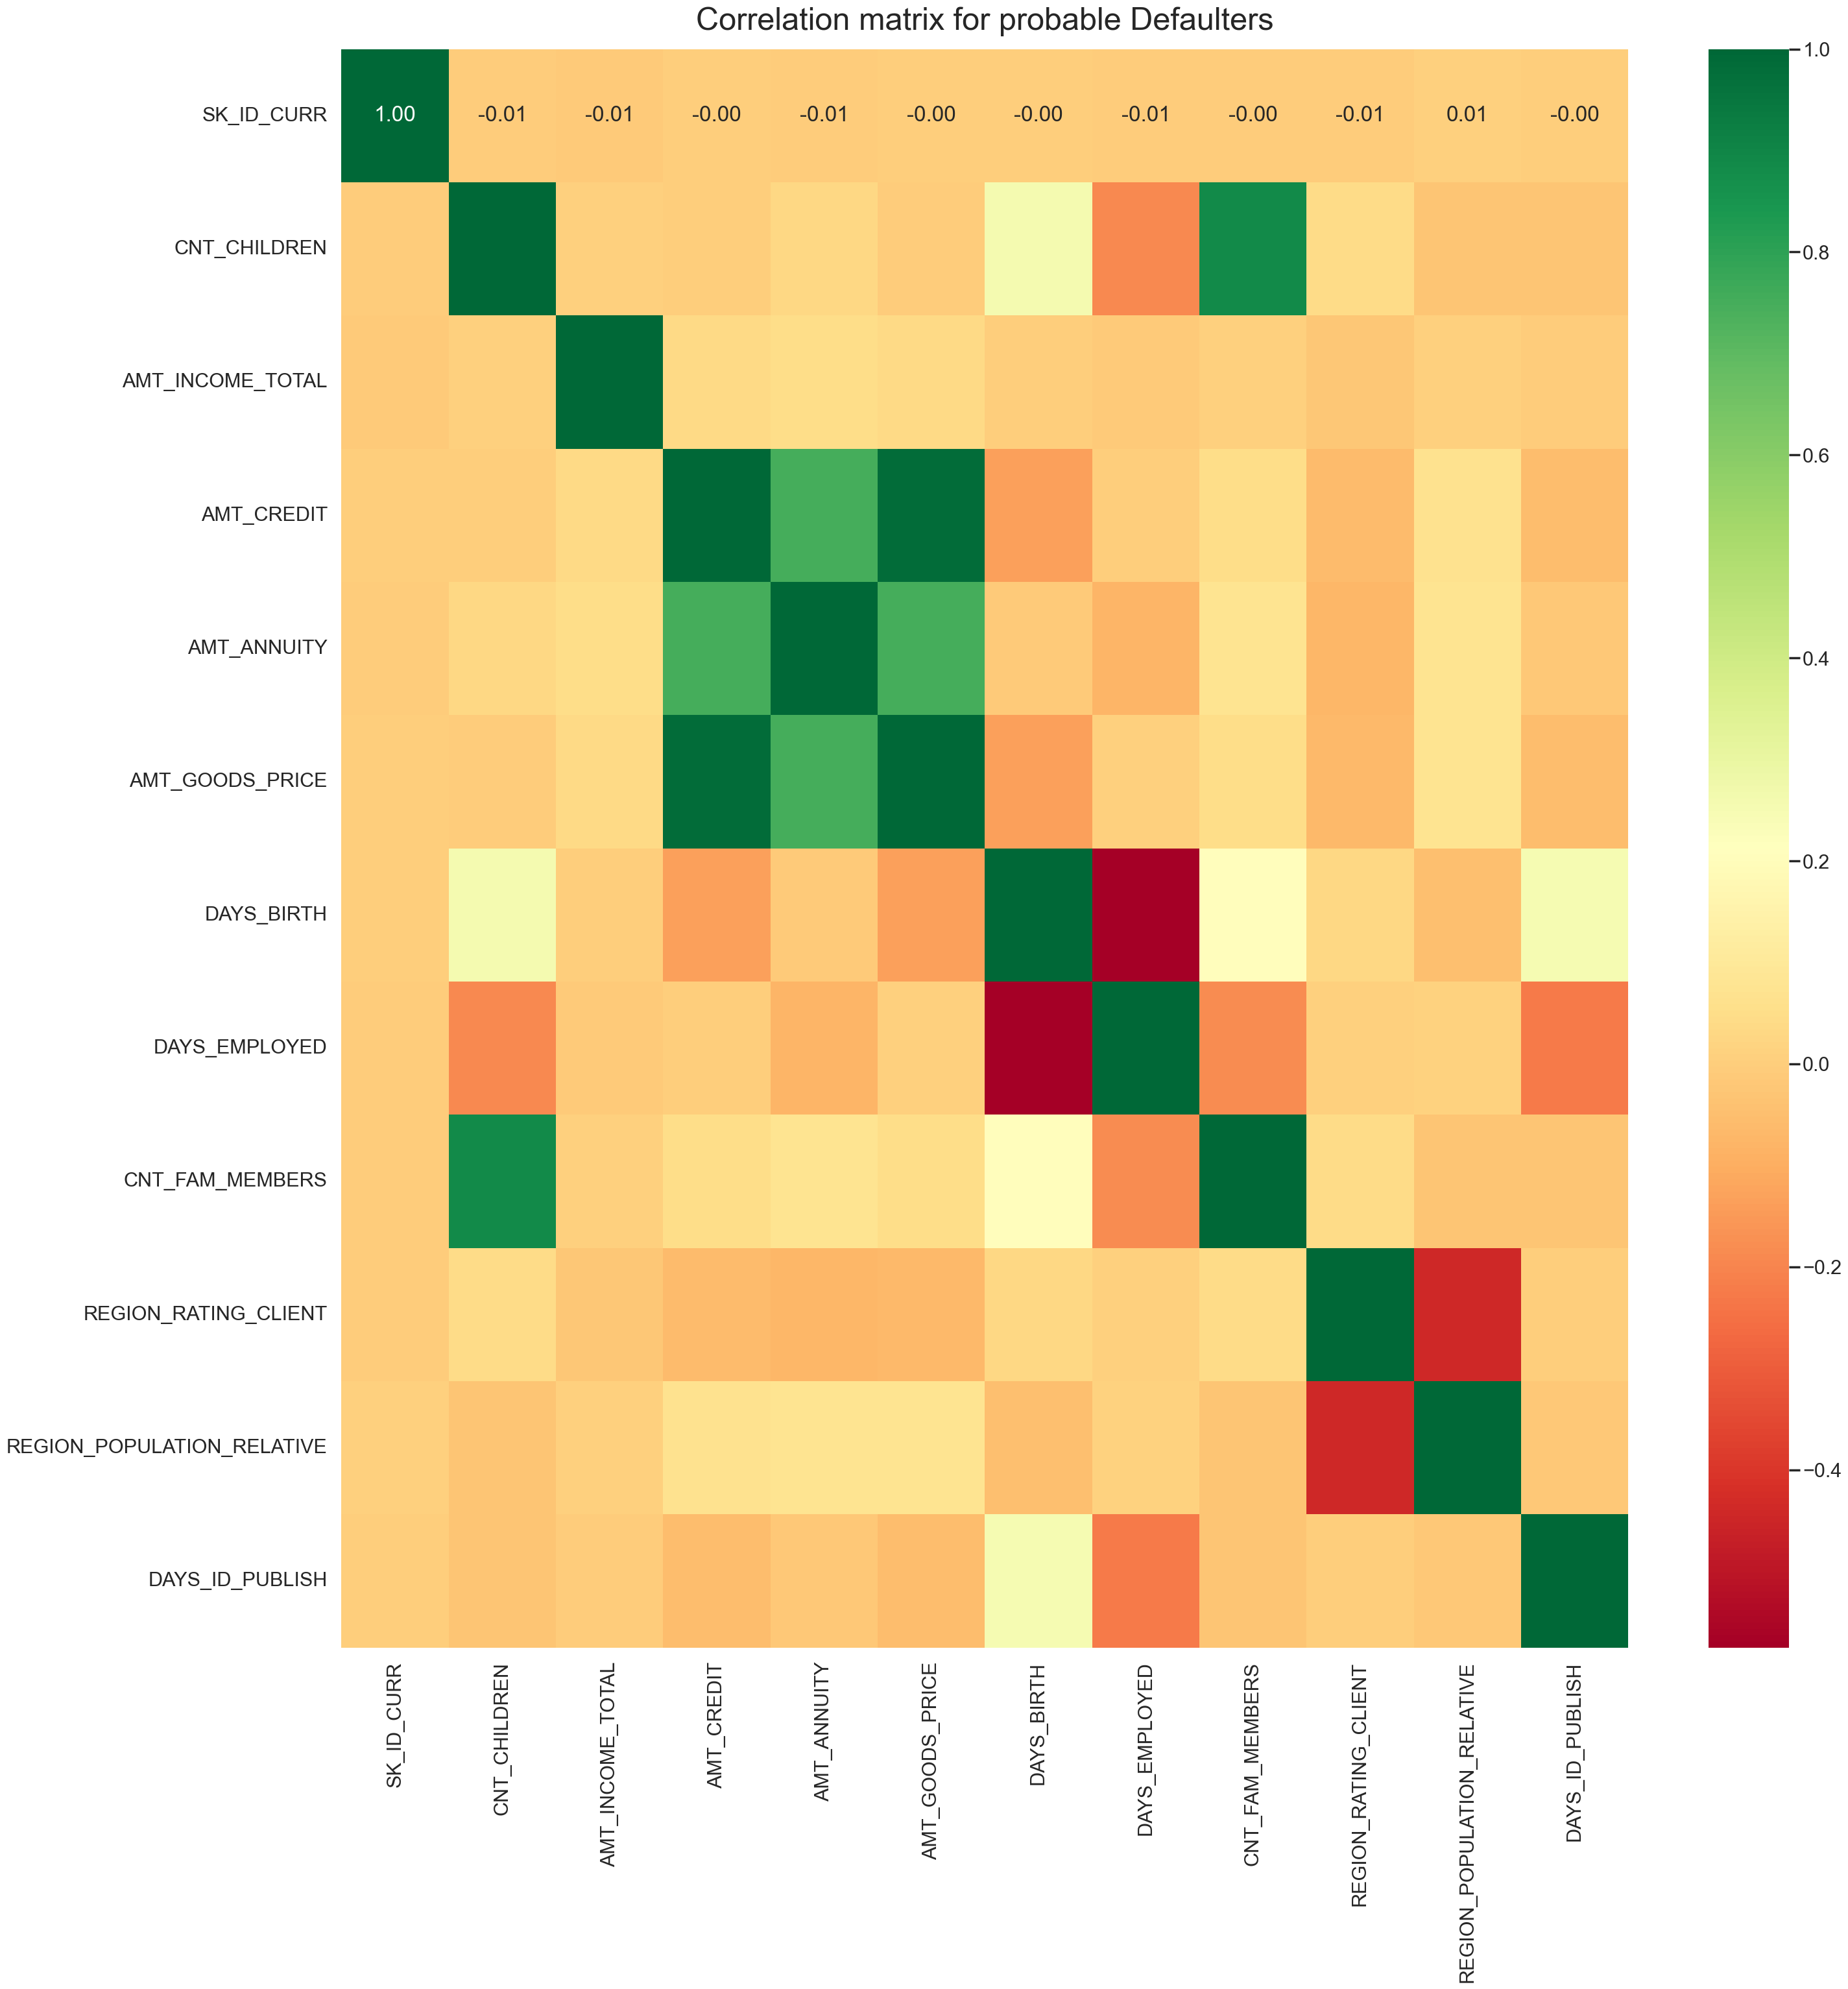

In [423]:
#Plotting the Correlation matrix for Target_1 appl_data
n=target_1[['SK_ID_CURR','CNT_CHILDREN','AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE','DAYS_BIRTH','DAYS_EMPLOYED','CNT_FAM_MEMBERS',
            'REGION_RATING_CLIENT','REGION_POPULATION_RELATIVE','DAYS_ID_PUBLISH']]
f, ax = plt.subplots(figsize=(32, 32))
sns.heatmap(n.corr(), fmt='.2f', cmap="RdYlGn", annot=True)
plt.title("Correlation matrix for probable Defaulters",fontsize=35, pad=22 )
plt.show()

Text(0.5, 1.0, 'Credit Amount vs Education Status For Target_0')

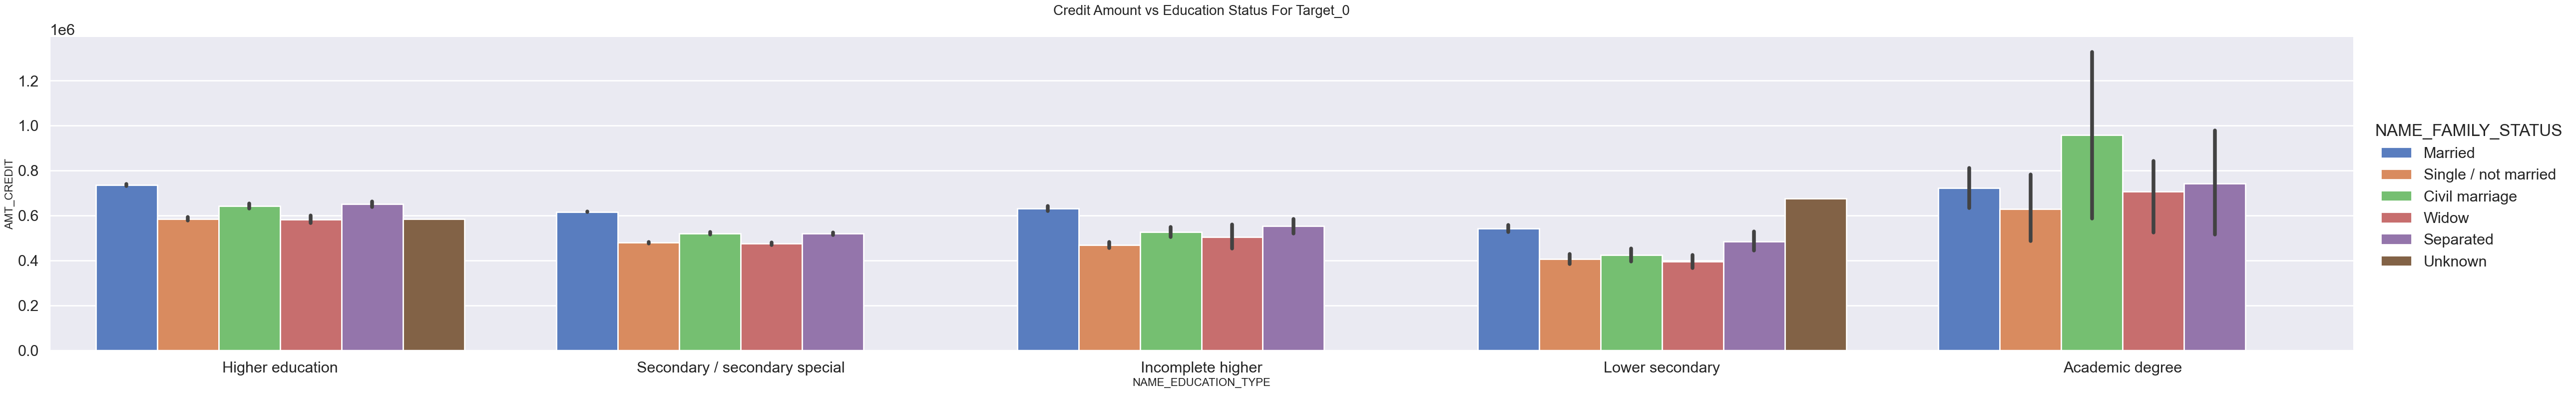

In [430]:
#Inquiry of Credit amount to Education status
#Plotting of the NAME_EDUCATION_TYPE vs AMT_CREDIT for Target_0 for each family status 
sns.catplot(data =target_0, x='NAME_EDUCATION_TYPE',y='AMT_CREDIT', hue ='NAME_FAMILY_STATUS',height=8,aspect=6, kind="bar", palette="muted")
plt.title('Credit Amount vs Education Status For Target_0')


In [432]:
#Inference:
#Key observations from the above graph for target = 0 (Non-Defaulters):
#Customers with an academic degree have higher credit amounts, with the civil marriage segment having the highest credit.
#Lower educated customers tend to have lower credit amounts, with widows having the lowest.

Text(0.5, 1.0, 'Credit Amount vs Education Status for Traget_1')

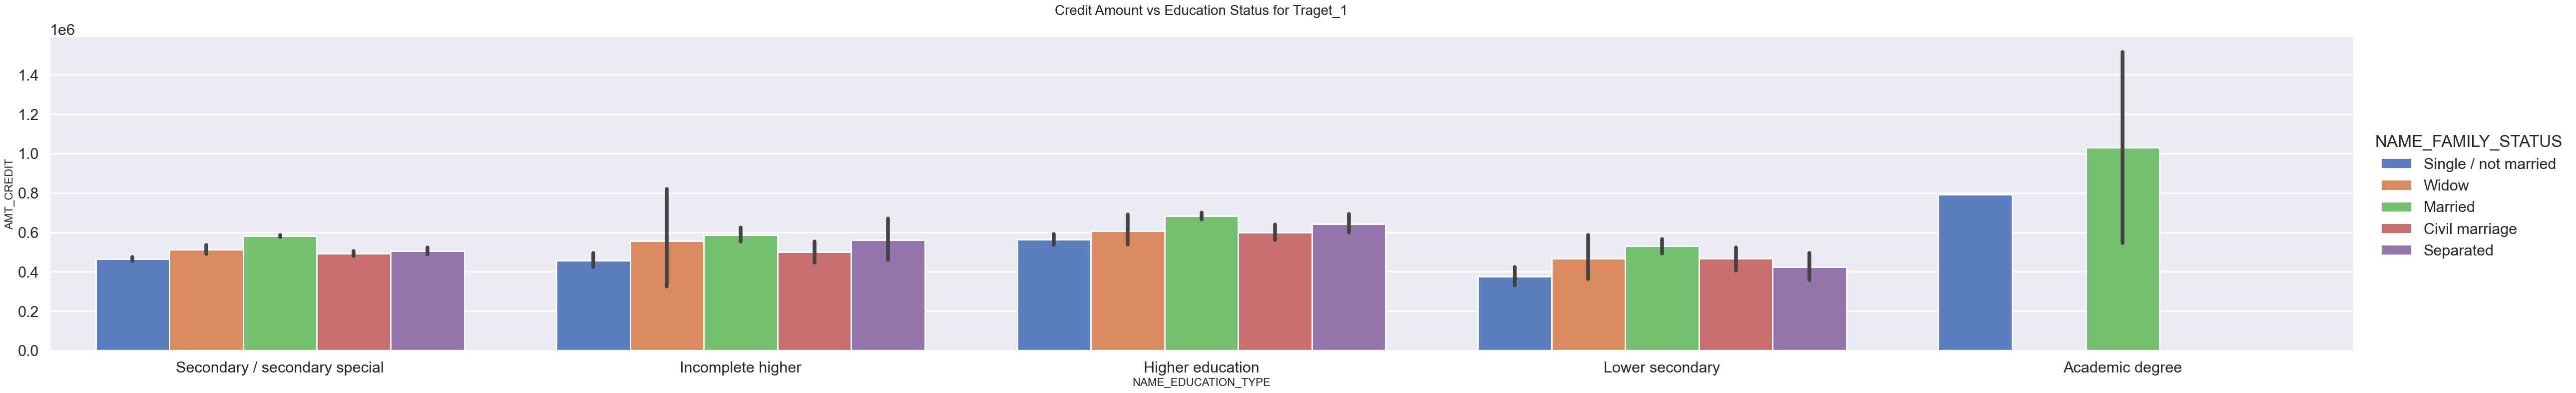

In [434]:
#Plotting of the NAME_EDUCATION_TYPE vs AMT_CREDIT for Target_1 for each family status 
sns.catplot(data =target_1, x='NAME_EDUCATION_TYPE',y='AMT_CREDIT', hue ='NAME_FAMILY_STATUS',height=8,aspect=6, kind="bar", palette="muted")
plt.title('Credit Amount vs Education Status for Traget_1')

In [436]:
#Inference:
#Key observations from the above graph for target = 1 (Defaulters):
#Married customers with academic degrees generally have higher credit amounts, which corresponds to a higher default rate.
#Across all education segments, married customers tend to have higher credit amounts.
#Customers with lower education levels tend to have lower credit amounts.
#Single and married are the only two family types present among those with academic degrees.

In [438]:
#Previous Application
prev_appl.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [440]:
#Find out the shape of the dataframe
prev_appl.shape

(1670214, 37)

In [442]:
#Find out the info of the dataframe
prev_appl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [444]:
#Find out the datatypes of each field in the dataframe
prev_appl.dtypes

SK_ID_PREV                       int64
SK_ID_CURR                       int64
NAME_CONTRACT_TYPE              object
AMT_ANNUITY                    float64
AMT_APPLICATION                float64
AMT_CREDIT                     float64
AMT_DOWN_PAYMENT               float64
AMT_GOODS_PRICE                float64
WEEKDAY_APPR_PROCESS_START      object
HOUR_APPR_PROCESS_START          int64
FLAG_LAST_APPL_PER_CONTRACT     object
NFLAG_LAST_APPL_IN_DAY           int64
RATE_DOWN_PAYMENT              float64
RATE_INTEREST_PRIMARY          float64
RATE_INTEREST_PRIVILEGED       float64
NAME_CASH_LOAN_PURPOSE          object
NAME_CONTRACT_STATUS            object
DAYS_DECISION                    int64
NAME_PAYMENT_TYPE               object
CODE_REJECT_REASON              object
NAME_TYPE_SUITE                 object
NAME_CLIENT_TYPE                object
NAME_GOODS_CATEGORY             object
NAME_PORTFOLIO                  object
NAME_PRODUCT_TYPE               object
CHANNEL_TYPE             

In [448]:
#Finding out the total number of columns having null values more than 50%

emptycolumn=prev_appl.isnull().sum()
emptycolumn=emptycolumn[emptycolumn.values>(0.5*len(emptycolumn))]
len(emptycolumn)

15

In [450]:
#Deleting the 15 columns
emptycolumn = list(emptycolumn[emptycolumn.values>=0.5].index)
prev_appl.drop(labels=emptycolumn,axis=1,inplace=True)
prev_appl.shape

(1670214, 22)

In [452]:
#Removing XNA & XAP
prev_appl=prev_appl.drop(prev_appl[prev_appl['NAME_CASH_LOAN_PURPOSE']=='XNA'].index)
prev_appl=prev_appl.drop(prev_appl[prev_appl['NAME_CASH_LOAN_PURPOSE']=='XAP'].index)
prev_appl.shape

(69635, 22)

In [479]:
#Merging previous application dataset with application data
Merge_data=pd.merge(left=appl_data,right=prev_appl,how='inner',on='SK_ID_CURR',suffixes=('_', 'x'))

In [481]:
Merge_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE_,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_,AMT_ANNUITY,...,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,NAME_YIELD_GROUP
0,100034,0,Revolving loans,M,N,Y,0,90000.0,180000.0,9000.0,...,Cash through the bank,XAP,New,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,high
1,100035,0,Cash loans,F,N,Y,0,292500.0,665892.0,24592.5,...,Cash through the bank,HC,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,low_action
2,100039,0,Cash loans,M,Y,N,1,360000.0,733315.5,39069.0,...,Cash through the bank,XAP,Refreshed,XNA,Cash,walk-in,Channel of corporate sales,-1,XNA,low_normal
3,100046,0,Revolving loans,M,Y,Y,0,180000.0,540000.0,27000.0,...,Cash through the bank,XAP,New,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,low_normal
4,100046,0,Revolving loans,M,Y,Y,0,180000.0,540000.0,27000.0,...,Cash through the bank,LIMIT,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,low_normal


In [489]:
# Renaming the column names after merging
Merge_data = Merge_data.rename({'NAME_CONTRACT_TYPE_' : 'NAME_CONTRACT_TYPE','AMT_CREDIT_':'AMT_CREDIT','AMT_ANNUITY_':'AMT_ANNUITY',
                                'WEEKDAY_APPR_PROCESS_START_' : 'WEEKDAY_APPR_PROCESS_START','HOUR_APPR_PROCESS_START_':'HOUR_APPR_PROCESS_START',
                                'NAME_CONTRACT_TYPEx':'NAME_CONTRACT_TYPE_PREV','AMT_CREDITx':'AMT_CREDIT_PREV','AMT_ANNUITYx':'AMT_ANNUITY_PREV',
                                'WEEKDAY_APPR_PROCESS_STARTx':'WEEKDAY_APPR_PROCESS_START_PREV','HOUR_APPR_PROCESS_STARTx':'HOUR_APPR_PROCESS_START_PREV'},
                                 axis=1)

In [505]:
#Checking the shape of the Merged Data
Merge_data.shape

(59413, 132)

In [507]:
#Univariate analysis with the Merged data

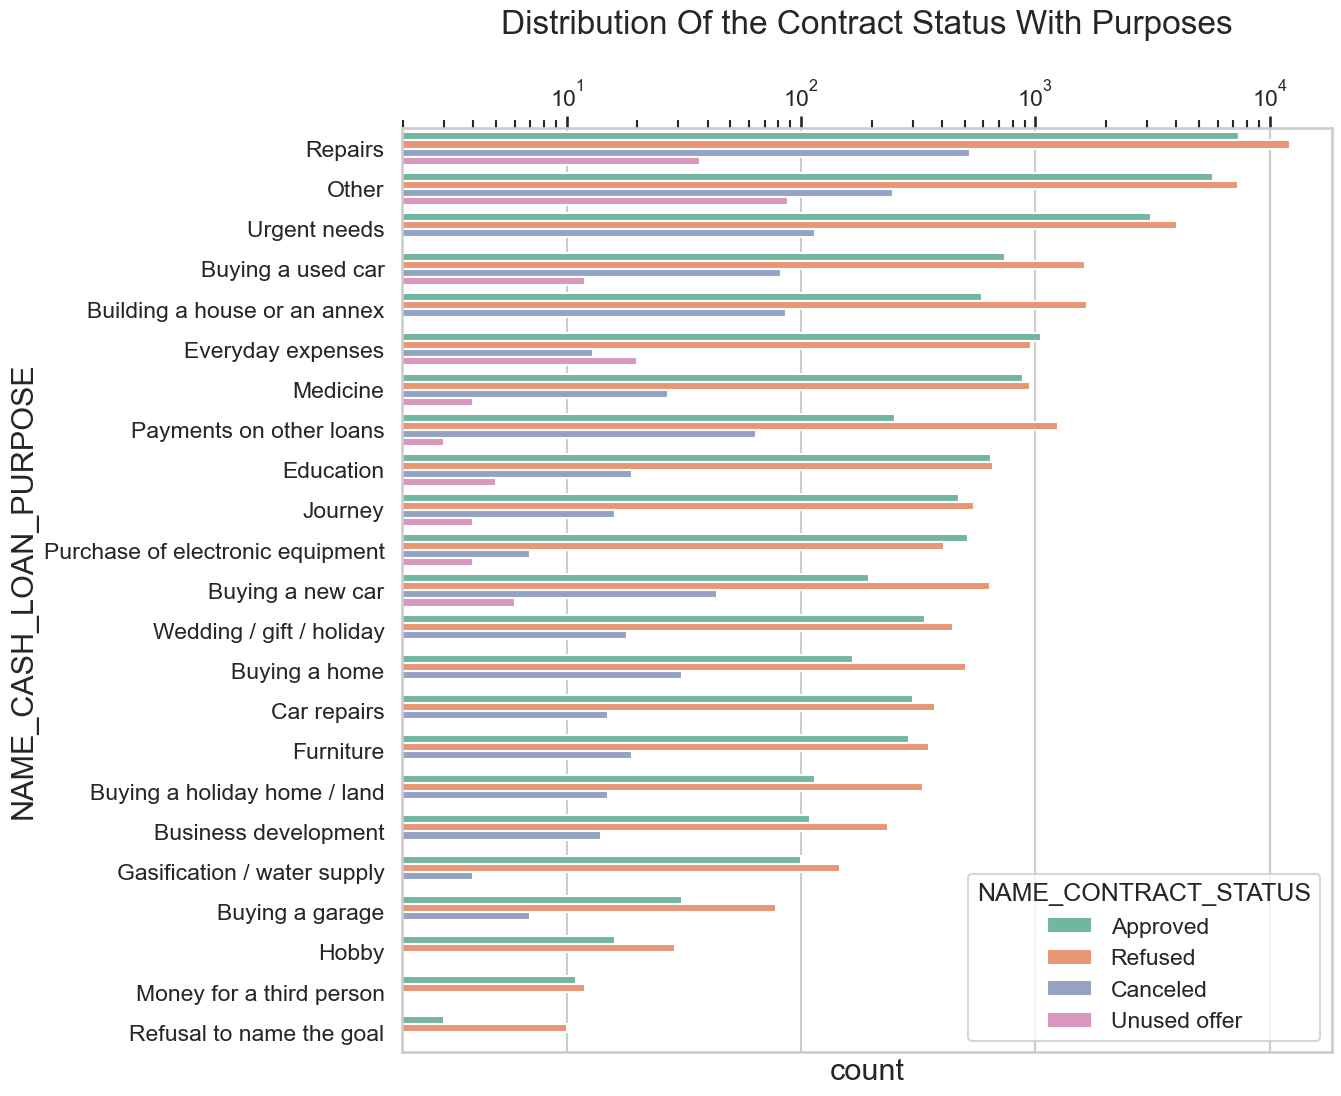

In [517]:
# Distribution of the contract status
sns.set_style('whitegrid')
sns.set_context('talk')
plt.figure(figsize=(12,12))
plt.rcParams["axes.labelsize"] = 22
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['axes.titlepad'] = 32
plt.title('Distribution Of the Contract Status With Purposes')
plt.xscale('log')

ax = sns.countplot(data = Merge_data, y= 'NAME_CASH_LOAN_PURPOSE',orient="h", order=Merge_data['NAME_CASH_LOAN_PURPOSE'].value_counts().index,hue= 'NAME_CONTRACT_STATUS',palette='Set2') 
ax.xaxis.tick_top()

In [515]:
#Key takeaway - The majority of loan rejections were for the purpose of 'Repairs'

In [519]:
#Bivariate analysis with the Merged data

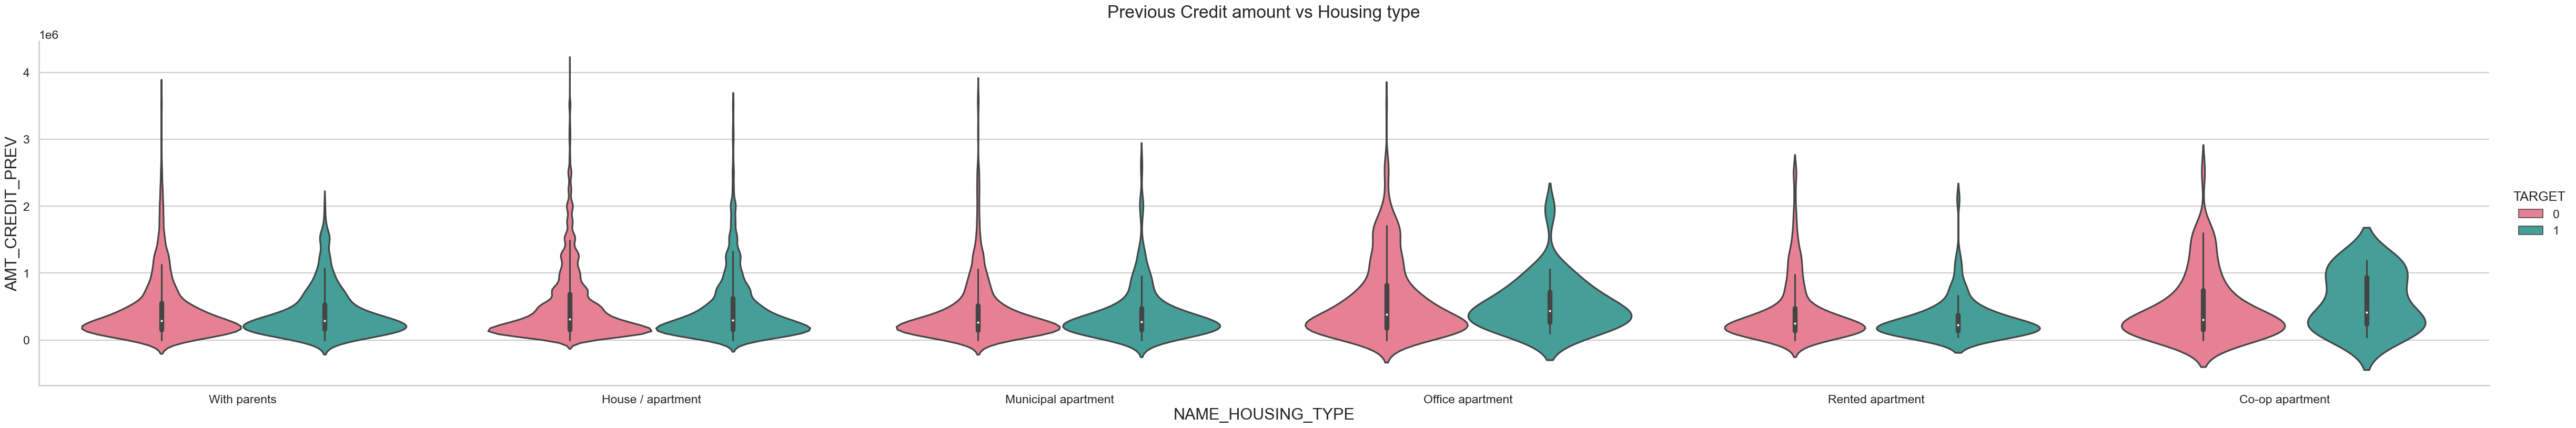

In [521]:
# Box Plot for Previous credit vs Housing type
sns.catplot(x="NAME_HOUSING_TYPE", y="AMT_CREDIT_PREV", hue="TARGET", data=Merge_data, kind="violin",height=8,aspect=6,palette='husl')
plt.title('Previous Credit amount vs Housing type')
plt.show()

In [523]:
#We can conclude that the bank should avoid giving loans for co-op apartments, as these applicants are experiencing difficulties with payments.